In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

from shared.cpcrr.methods.cokrigingfitter import CoKrigingFitter
from shared.cpcrr.functions import onevar, onevarAD
from shared.sample_funcs import peaks, peaksAD
from shared.sampling import random_latin_hypercube, space_filling_latin_hypercube, find_subset, align_subset

Done.
µ -3.435566222847853 σ2 26.936024080388496
θ [16.89778449]
θd [0.001]
rho 1.9997101385159124
globmean -3.435566222847853
globmeand 12.21423213040486
globvar 26.936024080388496
globvard 49445.92997996034


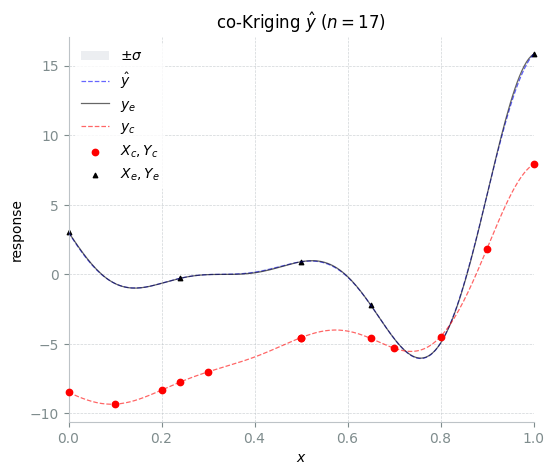

In [8]:
x_c = np.array([
    0,
    0.24,
    0.5,
    0.65,
    1.0,
    0.1,
    0.2,
    0.3,
    0.5,
    0.7,
    0.8,
    0.9
])
y_c = onevarAD(x_c)
nlow = x_c.shape[0]

x_e = datax = np.array([
    0.0,
    0.24,
    0.5,
    0.65,
    # 0.82,
    # 0.9,
    1.0,
])
y_e = onevar(x_e)

datax = np.concatenate([x_c, x_e])
datay = np.concatenate([y_c, y_e])

if len(datax.shape) == 1:
    datax = datax.reshape(-1,1)


CKF = CoKrigingFitter(
    xmin=(0,),
    xmax=(1,),
    datax=datax,
    datay=datay,
    nlow=nlow
)


# CKF.plot_check_inputs(objective=onevar)


CKF.fit(
    # verbose=True,
)


print("Done.")
print(f"µ {CKF.globmean} σ2 {CKF.globvar}")
print(f"θ {CKF.theta}")
print(f"θd {CKF.thetad}")
print(f"rho {CKF.rho}")
print(f"globmean {CKF.globmean}")
print(f"globmeand {CKF.globmeand}")
print(f"globvar {CKF.globvar}")
print(f"globvard {CKF.globvard}")

CKF.plot_check_model(objective_e=onevar, objective_c=onevarAD,res=200)

/home/ian/code/rceu-2026/src/shared/sampling.py:84: RuntimeWarning: overflow encountered in divide
  return sum(((J/(d**q))**(1/q)))


Done.
µ -4.876105066163345 σ2 0.7443627166407352
θ [0.9768957  1.12924076]
θd [0.20191969 6.98540186]
rho 2.000000000919664
globmean -4.876105066163345
globmeand 10.000000004293025
globvar 0.7443627166407352
globvard 1.3446090362368099e-18


<Figure size 600x500 with 0 Axes>

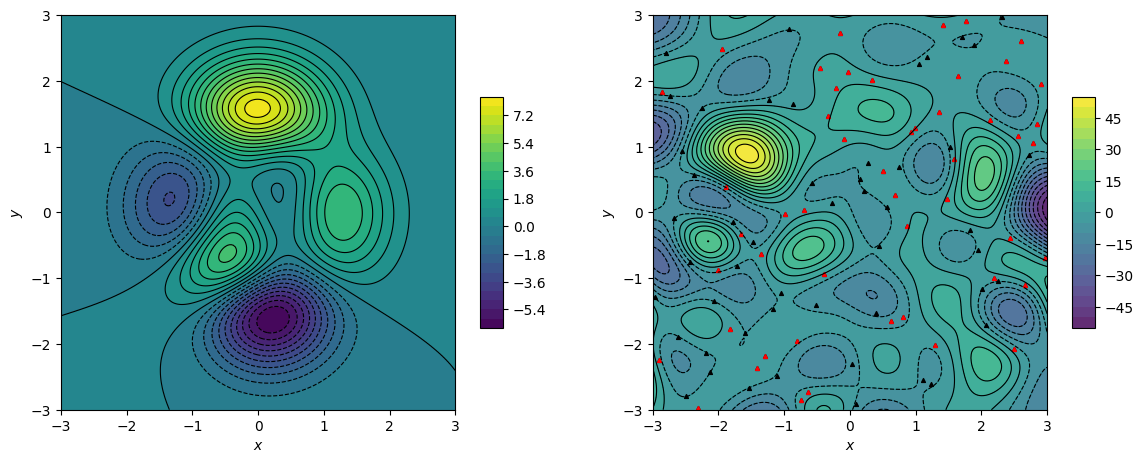

In [3]:
nlow = 100
nhigh = 50
k = 2

X_rlhc = random_latin_hypercube(nlow, k, [-3,-3],[3,3])
X_sample,q,_ = space_filling_latin_hypercube(X_rlhc)

subset = find_subset(X_sample, nhigh, q)
datax  = align_subset(X_sample,subset)

x_c = datax[:nlow]
x_e = datax[:nhigh]

y_c = peaksAD(x_c)
y_e = peaks(x_e)

datay = np.concatenate([y_c, y_e])


CKF = CoKrigingFitter(
    xmin=(-3,-3),
    xmax=(3,3),
    datax=datax,
    datay=datay,
    nlow=nlow,
    ill_conditioned=-500
)

CKF.fit(
    # verbose=True,
)


print("Done.")
print(f"µ {CKF.globmean} σ2 {CKF.globvar}")
print(f"θ {CKF.theta}")
print(f"θd {CKF.thetad}")
print(f"rho {CKF.rho}")
print(f"globmean {CKF.globmean}")
print(f"globmeand {CKF.globmeand}")
print(f"globvar {CKF.globvar}")
print(f"globvard {CKF.globvard}")

CKF.plot_check_model(objective_e=peaks, res=200)

Text(0.5, 1.0, '$\\hat{f}(x,y)$)')

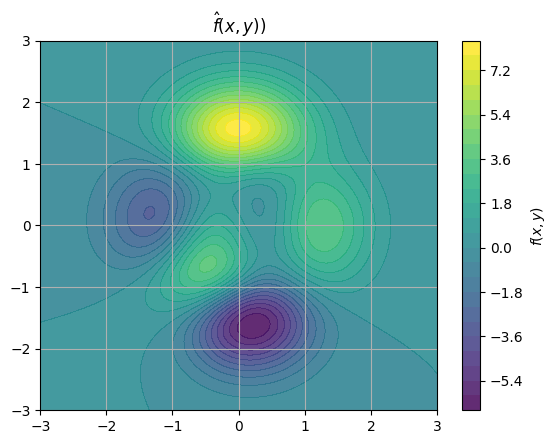

In [ ]:
Nside = 200
x = np.linspace(-3, 3, Nside)
y = np.linspace(-3, 3, Nside)
X, Y = np.meshgrid(x, y)
matr = np.hstack((X.reshape((-1, 1)), Y.reshape((-1, 1))))
Z_true = peaks(matr).reshape((Nside, Nside))


vmin, vmax = Z_true.min(), Z_true.max()
norm = Normalize(vmin=vmin, vmax=vmax)


contour = plt.contourf(X, Y, Z_true, levels=24, cmap='viridis', norm=norm, alpha=0.85)
# plot collocation points used to perform model fit

plt.colorbar(contour, label='$f(x,y)$')
plt.grid(True)
plt.title(rf"$\hat{{f}}(x,y)$)")

reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.variance
reconstraining parameters rbf.lengthscale
reconstraining parameters rbf.variance


Optimization restart 1/10, f = 369557.93662104843
Optimization restart 2/10, f = 48.82631485630485
Optimization restart 3/10, f = 36.36703164527801
Optimization restart 4/10, f = 48.82630609103629
Optimization restart 5/10, f = 37.28612462630781
Optimization restart 6/10, f = 36.36703165539018
Optimization restart 7/10, f = 36.36703164832711
Optimization restart 8/10, f = 36.367031643508064
Optimization restart 9/10, f = 36.36703164461582
Optimization restart 10/10, f = 36.36703164863506

Name : gp
Objective : 36.367031643508064
Number of Parameters : 7
Number of Optimization Parameters : 5
Updates : True
Parameters:
  gp.                                    |                value  |  constraints   |  priors
  multifidelity.rbf.variance             |    22.75406202053842  |  0.001,1000.0  |        
  multifidelity.rbf.lengthscale          |  0.13552321024415392  |   0.001,1.0    |        
  multifidelity.rbf_1.variance           |    68.57348067721762  |  0.001,1000.0  |        
  multi

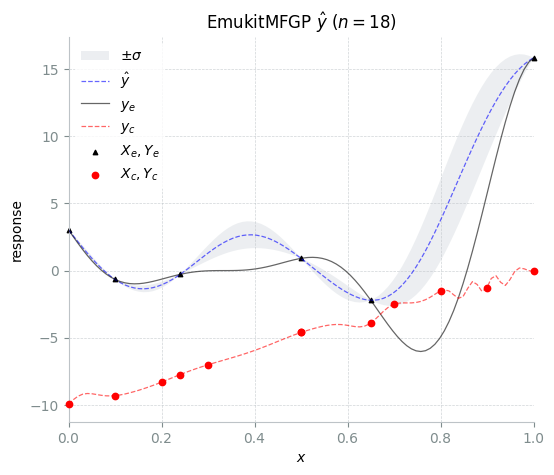

In [1]:
import numpy as np

from shared.sample_funcs import onevar, onevarSin
# from shared.cpcrr.functions import onevar, onevarAD
from shared.surrogates.emukitMFGP import EmukitMFGP
from shared.plotter import Plotter

x_c = np.array([
    0,
    0.24,
    0.5,
    0.65,
    1.0,
    0.1,
    0.2,
    0.3,
    0.5,
    0.7,
    0.8,
    0.9
])
nlow = x_c.shape[0]

x_e = np.array([
    0.0,
    0.24,
    0.5,
    0.65,
    0.82,
    # 0.9,
    1.0,
])

datax = np.concatenate([x_c, x_e])
if len(datax.shape) == 1:
    datax = datax.reshape(-1,1)

xmin=(0,)
xmax=(1,)
gp = EmukitMFGP(
    datax,
    onevar,
    onevarSin,
    nlow,
    xmin,
    xmax
)

print(gp.gpy_linear_mf_model)

plotter = Plotter(gp)

plotter.plot_check_model()

 /home/ian/code/rceu-2026/src/shared/sampling.py:84: RuntimeWarning:overflow encountered in power
 /home/ian/code/rceu-2026/src/shared/sampling.py:84: RuntimeWarning:divide by zero encountered in divide
reconstraining parameters Mat52.lengthscale
reconstraining parameters Mat52.lengthscale
reconstraining parameters Mat52.variance
reconstraining parameters Mat52.lengthscale
reconstraining parameters Mat52.lengthscale
reconstraining parameters Mat52.variance


Optimization restart 1/30, f = -23.22564295533256
Optimization restart 2/30, f = -39.891267464322965
Optimization restart 3/30, f = -39.891267347809446
Optimization restart 4/30, f = -39.891260852843644
Optimization restart 5/30, f = -39.891267715011026
Optimization restart 6/30, f = -39.88856478631132
Optimization restart 7/30, f = -39.89126681183308
Optimization restart 8/30, f = -23.225611171377423
Optimization restart 9/30, f = -39.89126724725553
Optimization restart 10/30, f = -39.89126763033126
Optimization restart 11/30, f = -39.89020080871117
Optimization restart 12/30, f = -39.89121230929152
Optimization restart 13/30, f = -39.89126727539903
Optimization restart 14/30, f = -39.890863165943585
Optimization restart 15/30, f = -39.89126610730196
Optimization restart 16/30, f = -39.89126771302681
Optimization restart 17/30, f = -23.225596264576964
Optimization restart 18/30, f = -39.88734636011118
Optimization restart 19/30, f = -39.89126602044996
Optimization restart 20/30, f = -

<Figure size 600x500 with 0 Axes>

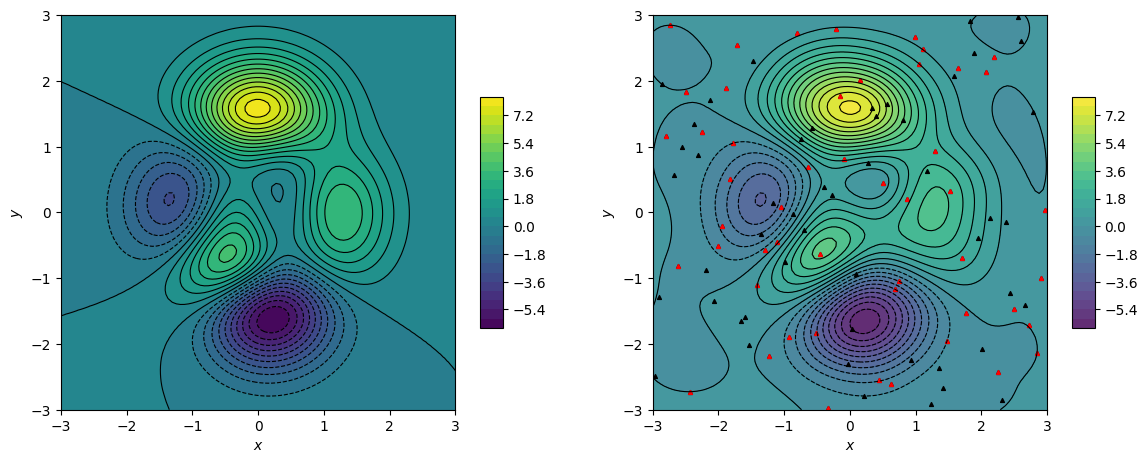

In [4]:
from shared.sample_funcs import peaks, peaksAD
from shared.surrogates.emukitMFGP import EmukitMFGP
from shared.plotter import Plotter
from shared.sampling import random_latin_hypercube, space_filling_latin_hypercube, find_subset, align_subset

nlow = 100
nhigh = 50
k = 2

X_rlhc = random_latin_hypercube(nlow, k, [-3,-3],[3,3])
X_sample,q,_ = space_filling_latin_hypercube(X_rlhc)

subset = find_subset(X_sample, nhigh, q)
datax  = align_subset(X_sample,subset)

xmin=(-3,-3)
xmax=(3,3)

gp = EmukitMFGP(datax, peaks, peaksAD, nlow, xmin, xmax)
print(gp.gpy_linear_mf_model)

plotter = Plotter(gp)

plotter.plot_check_model()